In [3]:
# ==============================
# 1. Import libraries
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
from google.colab import drive
drive.mount('/content/drive')

import joblib

Mounted at /content/drive


In [7]:
# ==============================
# 2. Load dataset
# ==============================

df = pd.read_csv("/content/drive/MyDrive/AiStudio/full_dataset_final.csv")

df.head()

,cleaned_log,label,source
0,packetresponder for block block_id terminating,0,HDFS
1,packetresponder for block block_id terminating,0,HDFS
2,block hostname blockmap updated ip_addr num is...,0,HDFS
3,packetresponder for block block_id terminating,0,HDFS
4,packetresponder for block block_id terminating,0,HDFS


In [8]:
# ==============================
# 3. Basic dataset stats
# ==============================

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nSource distribution:")
print(df["source"].value_counts())

Dataset shape: (7254, 3)

Columns:
Index(['cleaned_log', 'label', 'source'], dtype='object')

Data types:
cleaned_log    object
label           int64
source         object
dtype: object

Missing values:
cleaned_log    7
label          0
source         0
dtype: int64

Duplicate rows: 5836

Label distribution:
label
0    4687
1    2567
Name: count, dtype: int64

Source distribution:
source
HDFS            2000
OpenSSH         2000
Linux           2000
cloud_syslog    1129
cloud_auth       125
Name: count, dtype: int64


In [9]:
# ==============================
# 4. Data cleaning
# ==============================

df = df.drop_duplicates()

df["cleaned_log"] = df["cleaned_log"].fillna("")
df["source"] = df["source"].fillna("Unknown")

df["cleaned_log"] = df["cleaned_log"].astype(str).str.lower().str.strip()
df["source"] = df["source"].astype(str).str.strip()

df = df.dropna(subset=["label"])

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (1418, 3)


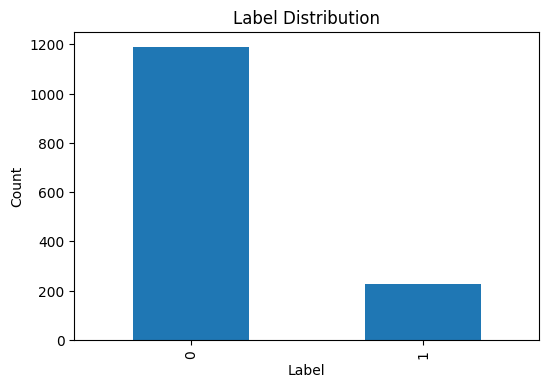

In [10]:
# ==============================
# 5. Graphs for data understanding
# ==============================

plt.figure(figsize=(6,4))
df["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

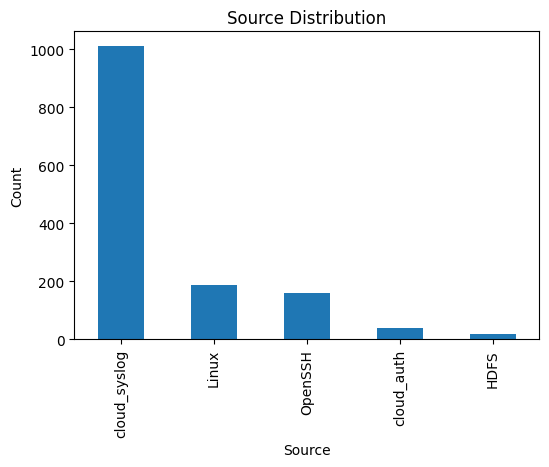

In [11]:
plt.figure(figsize=(6,4))
df["source"].value_counts().plot(kind="bar")
plt.title("Source Distribution")
plt.xlabel("Source")
plt.ylabel("Count")
plt.show()

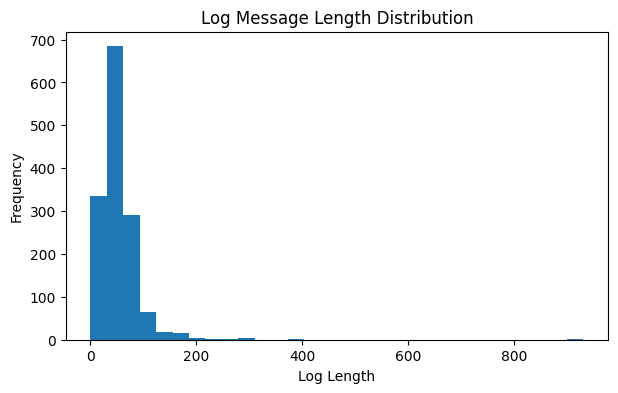

In [12]:
df["log_length"] = df["cleaned_log"].apply(len)

plt.figure(figsize=(7,4))
plt.hist(df["log_length"], bins=30)
plt.title("Log Message Length Distribution")
plt.xlabel("Log Length")
plt.ylabel("Frequency")
plt.show()

<Figure size 700x400 with 0 Axes>

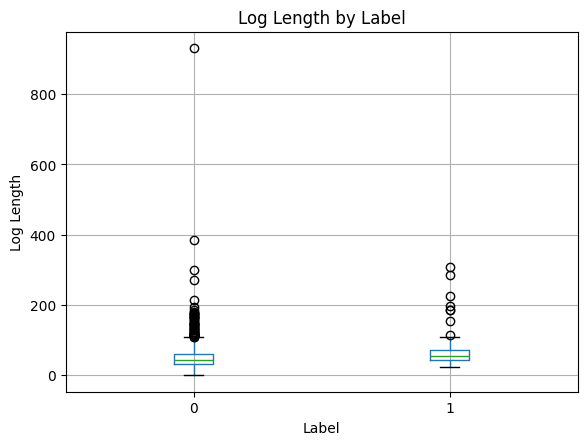

In [13]:
plt.figure(figsize=(7,4))
df.boxplot(column="log_length", by="label")
plt.title("Log Length by Label")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Log Length")
plt.show()

In [14]:
# ==============================
# 6. Define X and y
# ==============================

X = df[["cleaned_log", "source"]]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 1134
Testing rows: 284


In [15]:
# ==============================
# 7. Preprocessing and Random Forest model
# ==============================

preprocessor = ColumnTransformer(
    transformers=[
        ("log_text", TfidfVectorizer(max_features=3000, ngram_range=(1,2)), "cleaned_log"),
        ("source_cat", OneHotEncoder(handle_unknown="ignore"), ["source"])
    ]
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    max_depth=None,
    n_jobs=-1
)

pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", rf_model)
    ]
)

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('log_text',
                                                  TfidfVectorizer(max_features=3000,
                                                                  ngram_range=(1,
                                                                               2)),
                                                  'cleaned_log'),
                                                 ('source_cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['source'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [16]:
# ==============================
# 8. Model prediction and accuracy
# ==============================

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9753521126760564

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       239
           1       1.00      0.84      0.92        45

    accuracy                           0.98       284
   macro avg       0.99      0.92      0.95       284
weighted avg       0.98      0.98      0.97       284



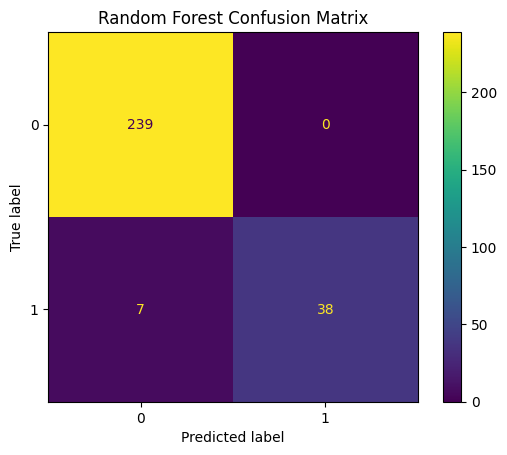

In [17]:
# ==============================
# 9. Confusion matrix graph
# ==============================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

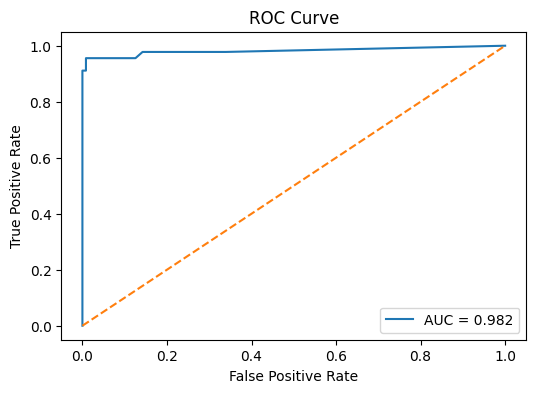

In [18]:
# ==============================
# 10. ROC Curve for binary classification
# ==============================

if len(np.unique(y)) == 2:
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

In [19]:
# ==============================
# 11. Feature importance graph
# ==============================

feature_names = pipeline.named_steps["preprocessing"].get_feature_names_out()
importances = pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

importance_df.head(20)

,feature,importance
3001,source_cat__source_Linux,0.095048
1393,log_text__invalid,0.064776
2814,log_text__user,0.064070
1395,log_text__invalid user,0.062122
3004,source_cat__source_cloud_syslog,0.049813
838,log_text__from,0.039183
1424,log_text__ip_addr,0.036612
846,log_text__from ip_addr,0.028391
1336,log_text__input_userauth_request invalid,0.024380
1335,log_text__input_userauth_request,0.022491


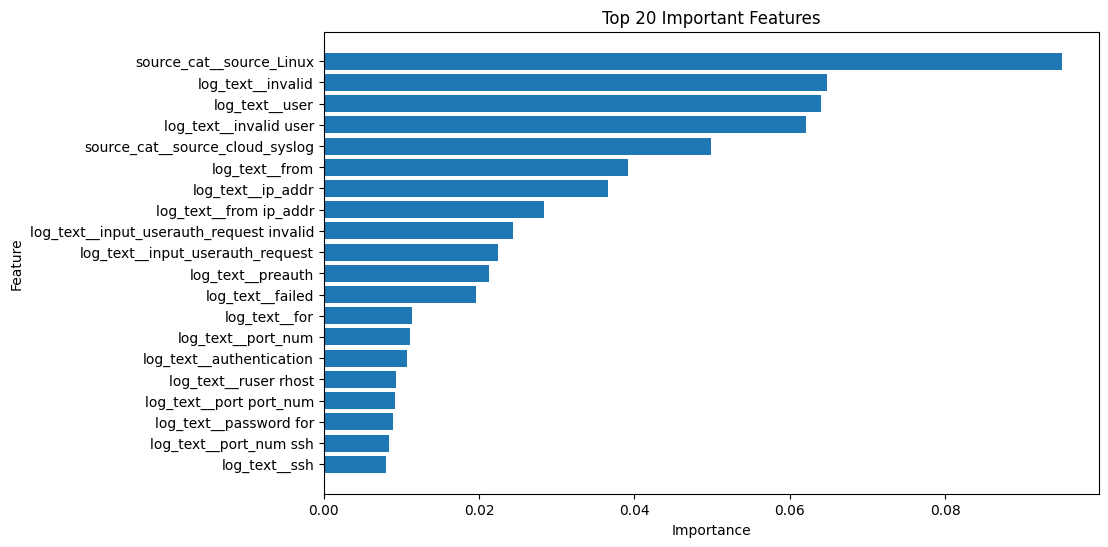

In [20]:
plt.figure(figsize=(10,6))
plt.barh(
    importance_df.head(20)["feature"][::-1],
    importance_df.head(20)["importance"][::-1]
)
plt.title("Top 20 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [21]:
# ==============================
# 12. Test with a custom log message
# ==============================

sample_log = pd.DataFrame({
    "cleaned_log": ["packetresponder for block block_id terminating"],
    "source": ["HDFS"]
})

prediction = pipeline.predict(sample_log)
probability = pipeline.predict_proba(sample_log)

print("Prediction:", prediction[0])
print("Prediction probability:", probability)

Prediction: 0
Prediction probability: [[0.995 0.005]]


In [22]:
# ==============================
# 13. Save model
# ==============================

joblib.dump(pipeline, "random_forest_log_model.pkl")

print("Model saved as random_forest_log_model.pkl")

Model saved as random_forest_log_model.pkl
